# MLP on PLAsTiCC: using avocado features extracted from GP-fitted lightcurves

This notebook uses the `dlip_plasticc` package on top of `avocado`.

### Notebook parameters

In [33]:
# ── Notebook parameters ──────────────────────────────────────────────────────

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH   = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# ── Training ─────────────────────────────────────────────────────────────────
TRAIN_DATASET_NAME  = 'plasticc_augment_daniil'
CLASSIFIER_NAME     = 'my_mlp_gp'
NUM_EPOCHS          = 100
BATCH_SIZE          = 256
LR                  = 5e-4
AUTO_CLASS_WEIGHTS  = True

HIDDEN_DIMS         = (256, 128, 64)
DROPOUT             = 0.3
USE_BATCH_NORM      = True
STANDARDIZE         = True
LABEL_SMOOTHING     = 0.0
TRACK_FLAT_SCORE    = True

# ── Fold / training settings ─────────────────────────────────────────────────
NUM_FOLDS               = 5
RANDOM_STATE            = 42
VAL_FOLD                = 0
WEIGHT_DECAY            = 5e-4
LR_SCHEDULER_FACTOR     = 0.5
LR_SCHEDULER_PATIENCE   = 3
MIN_LR                  = 1e-6
EARLY_STOPPING_PATIENCE = 15

# ── Precomputed training features ────────────────────────────────────────────
TRAIN_FEATURE_PATH = '/scratch/s4339150/plasticc/features/features_plasticc_augment_daniil.h5'
TRAIN_FEATURE_KEY  = 'raw_features'

# ── Prediction ───────────────────────────────────────────────────────────────
TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS      = 500
CHUNKS            = range(21)

FEATURE_BASE    = '/scratch/s4339150/plasticc/features/chunks/test/'
FEATURE_PATTERN = 'features_test_chunk_{chunk}_plasticc_test.h5'
FEATURE_KEY     = 'raw_features'

# Output location for per-chunk and combined predictions.
OUT_DIR = '/scratch/s4339150/plasticc/predictions/mlp_gp_predictions'

# ── Plot settings ────────────────────────────────────────────────────────────
CONFUSION_NORMALIZE = 'true'
FIGSIZE_HISTORY     = (8, 5)
FIGSIZE_CONFUSION   = (10, 8)

### Imports

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.models import MLPClassifier
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions, score_redshift, score_kaggle
from dlip_plasticc.pipelines.predict import predict_partial_from_feature_chunks

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

### Paths

These are set by the `avocado_settings.json` file.

In [3]:
config = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(config)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])

Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


## 1. Train the MLP

### Create classifier

In [13]:
gp_featurizer = avocado.plasticc.PlasticcFeaturizer()

classifier = MLPClassifier(
    name=CLASSIFIER_NAME,
    featurizer=gp_featurizer,
    hidden_dims=HIDDEN_DIMS,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    dropout=DROPOUT,
    auto_class_weights=AUTO_CLASS_WEIGHTS,
    use_batch_norm=USE_BATCH_NORM,
    standardize=STANDARDIZE,
    label_smoothing=LABEL_SMOOTHING,
    track_flat_score=TRACK_FLAT_SCORE,
)

### Check training dataset

In [8]:
print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
train_dataset = avocado.load(TRAIN_DATASET_NAME, metadata_only=True)
print(f"Training samples: {len(train_dataset.metadata)}")

Loading training dataset 'plasticc_augment_daniil'...
Training samples: 95914


In [9]:
train_feature_path = Path(TRAIN_FEATURE_PATH)

print(f"Inspecting HDF5 keys in: {train_feature_path}")
with pd.HDFStore(train_feature_path, mode="r") as store:
    print(store.keys())

Inspecting HDF5 keys in: /scratch/s4339150/plasticc/features/features_plasticc_augment_daniil.h5
['/chunk_info', '/raw_features']


In [10]:
print("Loading precomputed raw GP features...")
train_raw_features = pd.read_hdf(train_feature_path, key=TRAIN_FEATURE_KEY)

if "object_id" in train_raw_features.columns:
    train_raw_features = train_raw_features.set_index("object_id")

print("Raw feature table shape:", train_raw_features.shape)
display(train_raw_features.head())

Loading precomputed raw GP features...
Raw feature table shape: (95914, 230)


,host_specz,host_photoz,host_photoz_error,ra,decl,mwebv,ddf,count,gp_fit_0,gp_fit_1,...,peaks_neg_lsstr_frac_3,peaks_neg_lssti_count,peaks_neg_lssti_frac_2,peaks_neg_lssti_frac_3,peaks_neg_lsstz_count,peaks_neg_lsstz_frac_2,peaks_neg_lsstz_frac_3,peaks_neg_lssty_count,peaks_neg_lssty_frac_2,peaks_neg_lssty_frac_3
object_id,,,,,,,,,,,,,,,,,,,,,
plasticc_000000615,0.0,0.0,0.0,349.0461,-61.9438,0.017000,True,352,11.133501,0.810587,...,0.986609,19,0.979853,0.944808,20,0.983326,0.979975,25,0.996985,0.992113
plasticc_000000615_aug_DDWYWFbQIW,0.0,0.0,0.0,349.0461,-61.9438,0.019936,True,227,10.833345,0.620906,...,0.897508,15,0.999006,0.991734,15,0.992824,0.991149,20,0.993035,0.989519
plasticc_000000615_aug_IiBFsrtCeF,0.0,0.0,0.0,349.0461,-61.9438,0.015396,False,126,11.499572,3.459996,...,0.957900,11,0.886936,0.757448,5,0.789977,0.773771,6,0.851780,0.760846
plasticc_000000615_aug_JPPyffYqkF,0.0,0.0,0.0,349.0461,-61.9438,0.012922,False,127,11.652434,0.000000,...,0.669025,21,0.984502,0.795522,19,0.796143,0.788979,22,0.958317,0.859174
plasticc_000000615_aug_JRjIpoBpnJ,0.0,0.0,0.0,349.0461,-61.9438,0.017653,False,136,10.242166,0.000000,...,0.789398,18,0.954555,0.924566,16,0.998461,0.955962,15,0.967297,0.938169


### Train

In [14]:
print(f"Training classifier '{CLASSIFIER_NAME}' from precomputed raw features...")
classifier.train(
    train_dataset,
    raw_features=train_raw_features,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")
print(f"Validation fold: {classifier.val_fold}")
print("Detected classes:", classifier.class_names)
print("Input dim:", classifier.input_dim)

Training classifier 'my_mlp_gp' from precomputed raw features...


Epochs:   1%|          | 1/100 [00:01<02:57,  1.79s/it]

Epoch 1  train=1.61446  train_acc=0.4089  val=0.99396  val_acc=0.6040  lr=5.00e-04


Epochs:   2%|▏         | 2/100 [00:03<02:43,  1.67s/it]

Epoch 2  train=1.05153  train_acc=0.5556  val=0.87187  val_acc=0.6444  lr=5.00e-04


...

Epoch 52  train=0.50746  train_acc=0.7503  val=0.60191  val_acc=0.7565  lr=3.13e-05


Epochs:  53%|█████▎    | 53/100 [02:59<01:17,  1.66s/it]

Epoch 53  train=0.50937  train_acc=0.7494  val=0.60059  val_acc=0.7599  lr=3.13e-05


Epochs:  53%|█████▎    | 53/100 [03:01<02:40,  3.42s/it]

Epoch 54  train=0.51309  train_acc=0.7490  val=0.60027  val_acc=0.7575  lr=3.13e-05
Early stopping at epoch 54.  Best val=0.59767
Best validation loss: 0.59767
Best validation loss: 0.59767
Validation fold: 0
Detected classes: [ 6 15 16 42 52 53 62 64 65 67 88 90 92 95]
Input dim: 41


In [15]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)


Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_mlp_gp.pkl


## 2. Plot training history

In [16]:
history_df = classifier.history.copy()
display(history_df.tail())

,epoch,train_loss,train_acc,val_loss,val_acc,lr,val_flat_score
49,50,0.510401,0.750049,0.607998,0.756394,0.000063,NaN
50,51,0.508072,0.750244,0.604441,0.761915,0.000031,NaN
51,52,0.507463,0.750349,0.601912,0.756550,0.000031,NaN
52,53,0.509367,0.749449,0.600594,0.759883,0.000031,NaN
53,54,0.513087,0.748954,0.600267,0.757539,0.000031,NaN


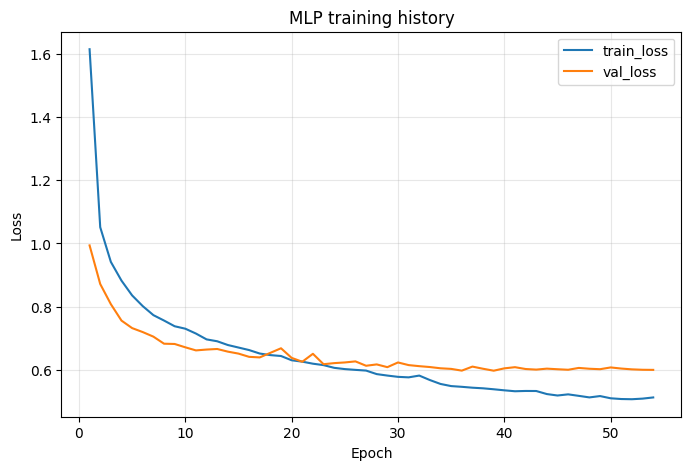

In [17]:
plt.figure(figsize=FIGSIZE_HISTORY)
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP training history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Predict on test chunks

In [24]:
classifier = avocado.load_classifier(CLASSIFIER_NAME)

In [34]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# full Daniil's test set features (not chunked, not preprocessed)
print("Loading test features from full feature file...")
test_features = pd.read_hdf(
    '/scratch/s4339150/plasticc/features/features_plasticc_test.h5',  
    key='raw_features'
)
print(f'Test features shape: {test_features.shape}')

print(f"Loading test metadata...")
test_dataset = avocado.load(TEST_DATASET_NAME, metadata_only=True)

# align metadata to only the objects we have features for
test_metadata = test_dataset.metadata.loc[
    test_dataset.metadata.index.intersection(test_features.index)
]

print(f'Objects to predict: {len(test_metadata)}')

print("Predicting...")
preds = classifier.predict(
    dataset=type('D', (), {'metadata': test_metadata})(),
    raw_features=test_features.loc[test_metadata.index],  # pass as raw_features, not features
)
preds.index = test_metadata.index
preds.index.name = 'object_id'

preds.to_hdf(f'{OUT_DIR}/predictions_mlp.h5', key='predictions', mode='w')
print(f'Saved {len(preds)} predictions to {OUT_DIR}/predictions_mlp.h5')

Loading test features from full feature file...
Test features shape: (349289, 230)
Loading test metadata...
Objects to predict: 349289
Predicting...


Predict: 100%|██████████| 1365/1365 [00:02<00:00, 565.45it/s]


Saved 349289 predictions to /scratch/s4339150/plasticc/predictions/mlp_gp_predictions/predictions_mlp.h5


## 4. Score predictions with avocado flat-weighted logloss

In [31]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, preds)
print(f'Flat-weighted log-loss: {flat_score:.5f}')
print(f'Objects scored:         {n_scored:,}')

Flat-weighted log-loss: 0.57461
Objects scored:         347,916


In [32]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, preds)
print(f"Flat-weighted logloss:     {flat_score:.5f}  (n={n_scored:,})")

redshift_score, n_scored = score_redshift(TEST_DATASET_NAME, preds)
print(f"Redshift-weighted logloss: {redshift_score:.5f}  (n={n_scored:,})")

kaggle_score, n_scored = score_kaggle(TEST_DATASET_NAME, preds)
print(f"Kaggle-weighted logloss:   {kaggle_score:.5f}  (n={n_scored:,})")

Flat-weighted logloss:     0.57461  (n=347,916)
Redshift-weighted logloss: 0.61096  (n=347,916)
Kaggle-weighted logloss:   0.61416  (n=347,916)


## 5. Confusion matrix and classification report

In [20]:
# Labels for plots

plot_labels = {
    6: 'Single micro-lens - 6',
    15: 'TDE - 15',
    16: 'Eclipsing Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_short = {
    6: 'Single $\mu$-lens - 6',
    15: 'TDE - 15',
    16: 'Eclip. Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_extra_short = {
    6: 'Single $\mu$-lens',
    15: 'TDE',
    16: 'Eclip. Binary',
    42: 'SNII',
    52: 'SNIax',
    53: 'Mira',
    62: 'SNIbc',
    64: 'Kilonova',
    65: 'M-dwarf',
    67: 'SNIa-91bg',
    88: 'AGN',
    90: 'SNIa',
    92: 'RR lyrae',
    95: 'SLSN-I',
    99: 'Unknown',
}

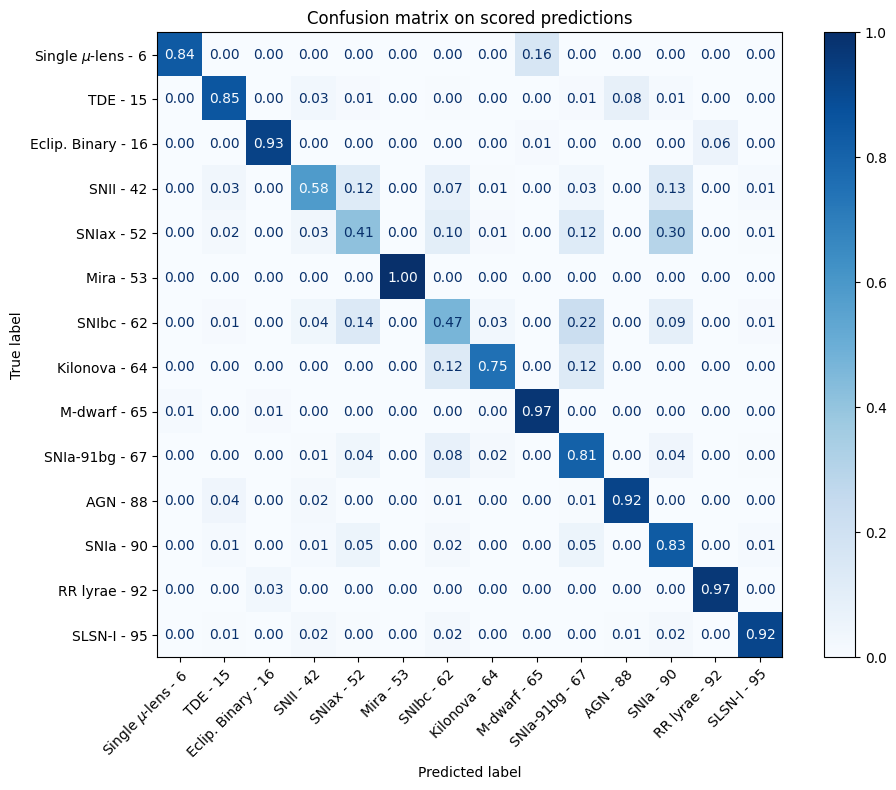

In [21]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    test_predictions,
    known_classes_only=True,
    normalize=True,
)

y_pred = pred_aligned.idxmax(axis=1)
labels = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

# map numeric class ids to readable labels
display_labels = [plot_labels_short.get(l, str(l)) for l in labels]

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels,  # readable labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
    cmap=plt.cm.Blues,
    values_format=".2f",
)

ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation=45, 
    ha='right',  # anchors the label end under the tick
    rotation_mode='anchor'
)

ax.set_title("Confusion matrix on scored predictions")
plt.tight_layout()
plt.show()